In this Jupiter notebook we will import a dataset from S3 bucket from AWS

aWe will use Duck DB as warehouse and NYC Taxi Dataset

In [1]:
# About the dataset
# •	Source: NYC Taxi & Limousine Commission (TLC), public domain, updated monthly
# •	Format: Parquet files hosted on a public S3 bucket, no credentials required
# •	Size: ~3 million rows per month, each file ~45 MB (2024 data)
# •	URL pattern: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_YYYY-MM.parquet
# •	Exercises use January–March 2024 (~9 million rows combined)


In [1]:
import duckdb

con = duckdb.connect('taxi.db')
con.execute('INSTALL httpfs; LOAD httpfs;')
BASE_URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data'


In [2]:
con.execute(f"""
  CREATE OR REPLACE VIEW taxi AS
  SELECT * FROM read_parquet([
    '{BASE_URL}/yellow_tripdata_2024-01.parquet',
    '{BASE_URL}/yellow_tripdata_2024-02.parquet',
    '{BASE_URL}/yellow_tripdata_2024-03.parquet'
  ])
""")

In [3]:
print(con.execute('SELECT COUNT(*) FROM taxi').fetchone())

(9554778,)


EXERCISE - find out what columns do we have here in view taxi - pro tip (use describe and summarise)

In [47]:
con.execute("DESCRIBE taxi;").fetchdf()

,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [48]:
con.execute("SUMMARIZE taxi;").fetchdf()


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,VendorID,INTEGER,1,6,3,1.7560020756107573,0.43124245631264957,2,2,2,9554778,0.00
1,tpep_pickup_datetime,TIMESTAMP,2002-12-31 22:17:10,2024-04-01 00:34:55,5128316,2024-02-17 17:20:27.204718,NaN,2024-01-26 07:27:30.52304,2024-02-18 07:36:11.004166,2024-03-11 14:21:03.713463,9554778,0.00
2,tpep_dropoff_datetime,TIMESTAMP,2002-12-31 22:42:24,2024-04-02 18:08:46,5941583,2024-02-17 17:36:34.800669,NaN,2024-01-26 08:22:42.906569,2024-02-18 16:30:34.713548,2024-03-11 08:55:07.243375,9554778,0.00
3,passenger_count,BIGINT,0,9,11,1.3344099206435758,0.8409249162511192,1,1,1,9554778,7.87
4,trip_distance,DOUBLE,0.0,312722.3,5335,4.0422861452144,265.47827357783484,0.9994961914399824,1.704139195797733,3.183572751531272,9554778,0.00
5,RatecodeID,BIGINT,1,99,7,2.1509001210521723,10.215182380094271,1,1,1,9554778,7.87
6,store_and_fwd_flag,VARCHAR,N,Y,2,NaN,NaN,NaN,NaN,NaN,9554778,7.87
7,PULocationID,INTEGER,1,265,290,165.2032947285641,64.05330206884267,132,162,234,9554778,0.00
8,DOLocationID,INTEGER,1,265,290,164.18751351418106,69.40855342677335,114,162,234,9554778,0.00
9,payment_type,BIGINT,0,4,5,1.1213880636473186,0.6106080298811776,1,1,1,9554778,0.00


-- but lets see how many files are in this bucket, we took only 3 and we have millions of records

In [5]:
import requests
count = 0

for year in range(2009, 2027):
    for month in range(1, 13):
        url = f"{BASE_URL}/yellow_tripdata_{year}-{month:02d}.parquet"

        r = requests.head(url)
        if r.status_code == 200:
            count += 1
            print(url)

print(f"\nTotal files: {count}")

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-01.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-02.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-03.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-04.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-05.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-06.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-07.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-08.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-09.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-10.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-11.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2009-12.parquet
https://d37ci6vzurychx.cloudfront.net/tr

KeyboardInterrupt: 

In [ ]:
# Pro tip
# You can swap any month by changing the URL, the schema is identical across all files.
# For faster iteration during development, append LIMIT 500000 to your queries or filter
# WHERE tpep_pickup_datetime >= '2024-01-01' AND tpep_pickup_datetime < '2024-01-08'
# to work on a single week before running against the full dataset.


In [5]:
kpis = con.execute("""
  SELECT
    COUNT(*)                                    AS total_trips,
    ROUND(AVG(trip_distance), 2)                AS avg_distance_miles,
    ROUND(AVG(fare_amount), 2)                  AS avg_fare_usd,
    ROUND(AVG(tip_amount / NULLIF(fare_amount,0)) * 100, 1) AS avg_tip_pct,
    ROUND(SUM(total_amount), 0)                 AS total_revenue_usd,
    ROUND(AVG(EPOCH(tpep_dropoff_datetime
               - tpep_pickup_datetime)/60), 1)  AS avg_duration_mins
  FROM taxi
  WHERE fare_amount   > 0
    AND trip_distance > 0
    AND tpep_pickup_datetime >= '2024-01-01'
    AND tpep_pickup_datetime <  '2024-02-01'
""").df()
print(kpis)

   total_trips  avg_distance_miles  avg_fare_usd  avg_tip_pct  \
0      2869707                3.73          18.5         21.4   

   total_revenue_usd  avg_duration_mins  
0         78481882.0               15.8  


Exercise= extend the above cell to also compute median fare using MEDIAN(fare_amount), compare it to the mean and explain the difference

In [49]:
exercise = con.execute("""SELECT
    COUNT(*) AS total_trips,
    ROUND(AVG(trip_distance), 2) AS avg_distance_miles,
    ROUND(AVG(fare_amount), 2) AS avg_fare_usd,
    ROUND(MEDIAN(fare_amount), 2) AS median_fare_usd,
    ROUND(AVG(tip_amount / NULLIF(fare_amount,0)) * 100, 1) AS avg_tip_pct,
    ROUND(SUM(total_amount), 0) AS total_revenue_usd,
    ROUND(AVG(EPOCH(tpep_dropoff_datetime - tpep_pickup_datetime) / 60), 1) AS avg_duration_mins
FROM taxi
WHERE fare_amount   > 0
  AND trip_distance > 0
  AND tpep_pickup_datetime >= DATE '2024-01-01'
  AND tpep_pickup_datetime <  DATE '2024-02-01';
""").df()
print(exercise.to_string())

   total_trips  avg_distance_miles  avg_fare_usd  median_fare_usd  avg_tip_pct  total_revenue_usd  avg_duration_mins
0      2869707                3.73          18.5             12.8         21.4         78481882.0               15.8


In [12]:
#hourly demand pattern
hourly = con.execute("""
  SELECT
    EXTRACT(hour FROM tpep_pickup_datetime) AS hour_of_day,
    COUNT(*)                                AS trips,
    ROUND(AVG(fare_amount), 2)              AS avg_fare
  FROM taxi
  WHERE tpep_pickup_datetime >= '2024-01-01'
    AND tpep_pickup_datetime <  '2024-02-01'
    AND fare_amount > 0
  GROUP BY hour_of_day
  ORDER BY hour_of_day
""").df()
print(hourly.to_string())

    hour_of_day   trips  avg_fare
0             0   77666     19.92
1             1   52668     18.17
2             2   36763     17.13
3             3   24244     19.02
4             4   16289     23.70
5             5   18366     27.69
6             6   40868     22.20
7             7   82907     18.90
8             8  116089     17.98
9             9  127685     18.06
10           10  137248     18.15
11           11  148849     17.82
12           12  162503     17.92
13           13  167816     18.56
14           14  180764     19.39
15           15  186997     19.26
16           16  187826     19.62
17           17  203768     18.28
18           18  210057     17.17
19           19  181661     17.78
20           20  157882     18.20
21           21  158725     18.46
22           22  141149     19.25
23           23  107486     20.44


In [13]:
#payment type breakdown
#payment_type: 1=Credit card, 2=Cash, 3=No charge, 4=Dispute
payments = con.execute("""
  SELECT
    CASE payment_type
      WHEN 1 THEN 'Credit card'
      WHEN 2 THEN 'Cash'
      WHEN 3 THEN 'No charge'
      WHEN 4 THEN 'Dispute'
      ELSE        'Unknown'
    END                                         AS method,
    COUNT(*)                                    AS trips,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct,
    ROUND(AVG(tip_amount), 2)                   AS avg_tip
  FROM taxi
  WHERE tpep_pickup_datetime >= '2024-01-01'
    AND tpep_pickup_datetime <  '2024-02-01'
  GROUP BY payment_type
  ORDER BY trips DESC
""").df()
print(payments)

        method    trips   pct  avg_tip
0  Credit card  2319044  78.2     4.17
1         Cash   439188  14.8     0.00
2      Unknown   140162   4.7     1.55
3      Dispute    46628   1.6     0.04
4    No charge    19595   0.7     0.01


Exercise: Add a day_of_week breakdown (use DAYNAME(tpep_pickup_datetime)), which day of the week generates the most revenue?
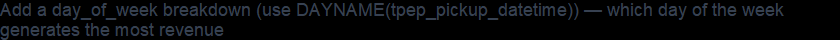

In [50]:
exercise = con.execute("""SELECT
    DAYNAME(tpep_pickup_datetime) AS day_name,
    ROUND(SUM(total_amount), 0) AS revenue_usd,
    ROUND(AVG(total_amount), 2) AS avg_trip_revenue_usd,
    COUNT(*) AS trips
FROM taxi
WHERE fare_amount > 0
  AND trip_distance > 0
  AND tpep_pickup_datetime >= DATE '2024-01-01'
  AND tpep_pickup_datetime <  DATE '2024-02-01'
GROUP BY DAYNAME(tpep_pickup_datetime)
ORDER BY revenue_usd DESC;
""").df()
print(exercise)

    day_name  revenue_usd  avg_trip_revenue_usd   trips
0  Wednesday   13231929.0                 27.52  480819
1    Tuesday   12417508.0                 27.65  449126
2   Thursday   11541132.0                 27.73  416209
3     Monday   11341473.0                 28.84  393252
4     Friday   10777655.0                 27.19  396385
5   Saturday   10265069.0                 25.21  407213
6     Sunday    8907116.0                 27.26  326703


Exercise: Filter to airport trips only: airport_fee > 0. How does average tip % compare to non-airport trips?

In [51]:
exercise = con.execute("""
SELECT ROUND(AVG(tip_amount / NULLIF(fare_amount,0) * 100), 1) AS avg_tip_pct_airport,
    COUNT(*) AS airport_trips
FROM taxi
WHERE airport_fee > 0
  AND fare_amount > 0
  AND trip_distance > 0;
""").df()
print(exercise.to_string())

   avg_tip_pct_airport  airport_trips
0                 17.4         700195


In [52]:
exercise = con.execute("""SELECT
    ROUND(AVG(tip_amount / NULLIF(fare_amount,0) * 100), 1) AS avg_tip_pct_nonairport,
    COUNT(*)                                                   AS nonairport_trips
FROM taxi
WHERE airport_fee = 0
  AND fare_amount > 0
  AND trip_distance > 0;""").df()
print(exercise.to_string())

   avg_tip_pct_nonairport  nonairport_trips
0                    21.8           7881771


Small tip: DuckDB's Parquet reader uses column projection, when your SELECT lists 4 columns out of 19,
it reads only those 4 columns from disk. The SUMMARIZE command exploits Parquet row-group
statistics (min/max stored in the file footer) to return column stats without decoding all data
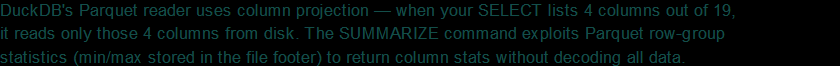

In [ ]:
##########################################################
#Identifying and quantifying data quality problems before analysis. Writing a repeatable cleaning query that removes invalid rows without losing too much data. Using QUALIFY to deduplicate. Asserting invariants programmatically so broken data fails loudly.
##########################################################

In [14]:
#Quantify every known quality problem in one query
audit = con.execute("""
  SELECT
    COUNT(*)                                             AS total_rows,
    COUNT(*) FILTER (WHERE fare_amount   <= 0)          AS neg_or_zero_fare,
    COUNT(*) FILTER (WHERE trip_distance <= 0)          AS zero_distance,
    COUNT(*) FILTER (WHERE passenger_count IS NULL
                       OR passenger_count <= 0)         AS bad_passengers,
    COUNT(*) FILTER (WHERE total_amount < fare_amount)  AS total_lt_fare,
    COUNT(*) FILTER (
      WHERE tpep_dropoff_datetime <= tpep_pickup_datetime
    )                                                    AS zero_neg_duration,
    COUNT(*) FILTER (
      WHERE EPOCH(tpep_dropoff_datetime
               - tpep_pickup_datetime)/3600 > 12
    )                                                    AS duration_over_12h,
    COUNT(*) FILTER (WHERE fare_amount > 500)           AS extreme_fare,
    COUNT(*) FILTER (WHERE trip_distance > 100)         AS extreme_distance
  FROM taxi
  WHERE tpep_pickup_datetime >= '2024-01-01'
    AND tpep_pickup_datetime <  '2024-02-01'
""").df()
print(audit.T)


                         0
total_rows         2964617
neg_or_zero_fare     38341
zero_distance        60372
bad_passengers      171627
total_lt_fare        35339
zero_neg_duration      870
duration_over_12h     1603
extreme_fare            46
extreme_distance        59


In [15]:
con.execute("""
  CREATE OR REPLACE VIEW taxi_clean AS
  SELECT
    tpep_pickup_datetime                                  AS pickup_dt,
    tpep_dropoff_datetime                                 AS dropoff_dt,
    COALESCE(passenger_count, 1)::INTEGER                AS passengers,
    trip_distance,
    PULocationID   AS pickup_zone,
    DOLocationID   AS dropoff_zone,
    payment_type,
    fare_amount,
    tip_amount,
    total_amount,
    congestion_surcharge,
    airport_fee,
    -- Derived columns computed once here, reused everywhere
    ROUND(EPOCH(tpep_dropoff_datetime
              - tpep_pickup_datetime) / 60.0, 2)         AS duration_mins,
    ROUND(trip_distance /
      NULLIF(EPOCH(tpep_dropoff_datetime
               - tpep_pickup_datetime) / 3600.0, 0), 2) AS speed_mph,
    ROUND(tip_amount / NULLIF(fare_amount, 0) * 100, 1)  AS tip_pct,
    CASE WHEN airport_fee > 0 THEN true ELSE false END   AS is_airport_trip
  FROM taxi
  WHERE fare_amount    > 0
    AND fare_amount    < 500
    AND trip_distance  > 0
    AND trip_distance  < 100
    AND tpep_dropoff_datetime > tpep_pickup_datetime
    AND EPOCH(tpep_dropoff_datetime
            - tpep_pickup_datetime) / 3600.0 < 12
""")

In [16]:
def assert_clean(con):
    checks = con.execute("""
      SELECT
        COUNT(*) FILTER (WHERE fare_amount <= 0)    AS bad_fare,
        COUNT(*) FILTER (WHERE duration_mins <= 0)  AS bad_duration,
        COUNT(*) FILTER (WHERE speed_mph > 200)     AS impossible_speed,
        COUNT(*) FILTER (WHERE tip_pct > 200)       AS extreme_tip
      FROM taxi_clean
    """).fetchone()

    bad_fare, bad_dur, bad_spd, ext_tip = checks
    if bad_spd > 0:
        print(f"⚠  Warning: {bad_spd} rows with speed > 200 mph — consider investigating")
    assert bad_fare  == 0, f'{bad_fare} rows with fare <= 0'
    assert bad_dur   == 0, f'{bad_dur} rows with duration <= 0'
    assert bad_spd   == 0, f'{bad_spd} rows with speed > 200 mph'
    print(f'All assertions passed. {ext_tip} rows with tip > 200% (kept).')

assert_clean(con)

⚠  Warning: 2171 rows with speed > 200 mph — consider investigating


AssertionError: 2171 rows with speed > 200 mph

In [17]:
# How many rows did cleaning remove?
raw   = con.execute("SELECT COUNT(*) FROM taxi").fetchone()[0]

In [18]:
clean = con.execute("SELECT COUNT(*) FROM taxi_clean").fetchone()[0]

In [19]:
print(f'Kept {clean/raw*100:.1f}% of rows ({raw-clean:,} removed)')

Kept 96.3% of rows (349,008 removed)


Exercise: after the audit, whitch quality issue affects most rows?

In [53]:
exercise = con.execute("""WITH base AS (
    SELECT *
    FROM taxi
    WHERE tpep_pickup_datetime >= DATE '2024-01-01'
      AND tpep_pickup_datetime < DATE '2024-02-01'
)
SELECT issue, cnt
FROM (
    SELECT 'fare <= 0' AS issue, COUNT(*) AS cnt FROM base WHERE fare_amount <= 0
    UNION ALL
    SELECT 'distance <= 0' AS issue, COUNT(*) FROM base WHERE trip_distance <= 0
    UNION ALL
    SELECT 'passenger_count <= 0' AS issue, COUNT(*) FROM base WHERE passenger_count <= 0
    UNION ALL
    SELECT 'total_amount < fare' AS issue, COUNT(*) FROM base WHERE total_amount < fare_amount
    UNION ALL
    SELECT 'duration <= 0 ' AS issue, COUNT(*) FROM base WHERE EPOCH(tpep_dropoff_datetime - tpep_pickup_datetime) <= 0
    UNION ALL
    SELECT 'duration > 12h' AS issue, COUNT(*) FROM base WHERE EPOCH(tpep_dropoff_datetime - tpep_pickup_datetime) > 12*3600
    UNION ALL
    SELECT 'fare > 500' AS issue, COUNT(*) FROM base WHERE fare_amount > 500
    UNION ALL
    SELECT 'distance > 100' AS issue, COUNT(*) FROM base WHERE trip_distance > 100
) q
ORDER BY cnt DESC
LIMIT 1;""").df()
print(exercise.to_string())

           issue    cnt
0  distance <= 0  60372


Exercise: After creating taxi_clean, compare average fare_amount and avg trip_distance between the raw and clean views

In [54]:
raw = con.execute("""SELECT
    ROUND(AVG(fare_amount), 2) AS avg_fare_raw,
    ROUND(AVG(trip_distance), 2) AS avg_distance_raw,
    COUNT(*) AS rows_raw
FROM taxi
WHERE fare_amount > 0
  AND trip_distance > 0;""").df()
print(raw.to_string())


   avg_fare_raw  avg_distance_raw  rows_raw
0         18.72              4.14   9211252


In [55]:
cleaned = con.execute("""SELECT
    ROUND(AVG(fare_amount), 2) AS avg_fare_clean,
    ROUND(AVG(trip_distance), 2)    AS avg_distance_clean,
    COUNT(*)                         AS rows_clean
FROM taxi_clean;""").df()
print(cleaned.to_string())

   avg_fare_clean  avg_distance_clean  rows_clean
0           18.71                 3.3     9205770


Exercise: Add a new dervied column: fare_per_mile = fare_amount / trip_distance. Filter out rows where fare_per_mile>50(likely errors). How many does this remove?

In [56]:
derived = con.execute("""WITH flagged AS (
    SELECT *
    FROM taxi_clean
    WHERE fare_amount / NULLIF(trip_distance,0) > 50
)
SELECT COUNT(*) AS rows_removed
FROM flagged;""").df()
print(derived.to_string())

   rows_removed
0         31534


Insight: COALESCE(passenger_count, 1) fills NULLs with a sensible default instead of dropping the row.
Computing derived columns (duration_mins, speed_mph, tip_pct) once in the view means every
downstream query gets them for free, no re-computation. NULLIF(x, 0) prevents division-by-zero
without needing CASE WHEN, keeping the SQL readable.

-----------------Joins and CTEs-------------------

Joining a large remote Parquet file with a small local CSV lookup table, a classic star-schema pattern. Using CTEs to break complex analysis into readable steps. Identifying the busiest pickup and dropoff zones in the city.
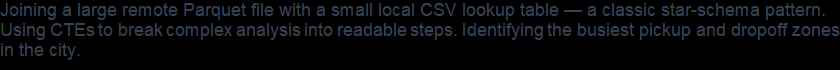

In [20]:
#download the zone lookup table
import urllib.request

# 265 zones with borough and neighbourhood names
url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv'
urllib.request.urlretrieve(url, 'taxi_zones.csv')

con.execute("""
  CREATE OR REPLACE TABLE taxi_zones AS
  SELECT
    LocationID   AS zone_id,
    Borough      AS borough,
    Zone         AS zone_name,
    service_zone
  FROM read_csv('taxi_zones.csv', auto_detect=true)
""")

print(con.execute('SELECT * FROM taxi_zones LIMIT 5').df())

   zone_id        borough                zone_name service_zone
0        1            EWR           Newark Airport          EWR
1        2         Queens              Jamaica Bay    Boro Zone
2        3          Bronx  Allerton/Pelham Gardens    Boro Zone
3        4      Manhattan            Alphabet City  Yellow Zone
4        5  Staten Island            Arden Heights    Boro Zone


In [21]:
#zone-level revenue CTE chain
zone_report = con.execute("""
  WITH
  -- Step A: aggregate trips per pickup zone
pickups AS (
    SELECT
      pickup_zone,
      COUNT(*)                            AS trips,
      ROUND(SUM(total_amount), 2)         AS revenue,
      ROUND(AVG(tip_pct), 1)              AS avg_tip_pct,
      ROUND(AVG(duration_mins), 1)        AS avg_duration
    FROM taxi_clean
    WHERE pickup_dt >= '2024-01-01'
      AND pickup_dt <  '2024-02-01'
    GROUP BY pickup_zone
  ),
  -- Step B: join to zone names
  named AS (
    SELECT
      z.borough,
      z.zone_name,
      p.trips,
      p.revenue,
      p.avg_tip_pct,
      p.avg_duration,
      -- Share of total revenue this zone represents
      ROUND(p.revenue / SUM(p.revenue) OVER () * 100, 2) AS revenue_share_pct
    FROM pickups p
    JOIN taxi_zones z ON p.pickup_zone = z.zone_id
  ),

  -- Step C: rank within each borough
  ranked AS (
    SELECT *,
      RANK() OVER (PARTITION BY borough ORDER BY revenue DESC) AS borough_rank
    FROM named
  )

  SELECT *
  FROM ranked
  WHERE borough_rank <= 5          -- top 5 zones per borough
  ORDER BY borough, borough_rank
""").df()
print(zone_report.to_string())

          borough                         zone_name   trips      revenue  avg_tip_pct  avg_duration  revenue_share_pct  borough_rank
0           Bronx                        Co-Op City     362     15943.14          0.3          46.6               0.02             1
1           Bronx            Mott Haven/Port Morris     436     12847.65          2.0          26.6               0.02             2
2           Bronx  East Concourse/Concourse Village     300      9533.89          0.7          38.8               0.01             3
3           Bronx             Soundview/Castle Hill     248      8761.93          0.4          38.9               0.01             4
4           Bronx                    West Concourse     278      8344.31          2.1          29.5               0.01             5
5        Brooklyn       Downtown Brooklyn/MetroTech    1293     42889.45         12.9          22.8               0.05             1
6        Brooklyn                  Brooklyn Heights    1167     38437

In [22]:
#most popular pickup-to-droppoff corridors
corridors = con.execute("""
  SELECT
    pu.zone_name  AS from_zone,
    do_.zone_name AS to_zone,
    pu.borough    AS from_borough,
    COUNT(*)      AS trips,
    ROUND(AVG(t.fare_amount), 2) AS avg_fare
  FROM taxi_clean t
  JOIN taxi_zones pu  ON t.pickup_zone  = pu.zone_id
  JOIN taxi_zones do_ ON t.dropoff_zone = do_.zone_id
  WHERE t.pickup_dt  >= '2024-01-01'
    AND t.pickup_dt  <  '2024-02-01'
  GROUP BY pu.zone_name, do_.zone_name, pu.borough
  ORDER BY trips DESC
  LIMIT 15
""").df()
print(corridors.to_string())


                       from_zone                    to_zone from_borough  trips  avg_fare
0          Upper East Side South      Upper East Side North    Manhattan  21634      8.90
1          Upper East Side North      Upper East Side South    Manhattan  19190      9.30
2          Upper East Side North      Upper East Side North    Manhattan  15185      6.82
3          Upper East Side South      Upper East Side South    Manhattan  14105      7.37
4                 Midtown Center      Upper East Side South    Manhattan  10139      9.89
5            Lincoln Square East      Upper West Side South    Manhattan   8819      8.06
6          Upper East Side South             Midtown Center    Manhattan   8716      9.80
7                 Midtown Center      Upper East Side North    Manhattan   8660     13.92
8          Upper West Side South        Lincoln Square East    Manhattan   8539      7.92
9          Upper West Side South      Upper West Side North    Manhattan   8302      7.21
10        

Exercise: after you ran the above 3 queries, whitch NYC borough generates the most revenue? Whitch zone has the highest avg_tip_pct?

In [57]:
most_revenue = con.execute("""SELECT
    borough,
    ROUND(SUM(total_amount), 0) AS revenue_usd
FROM taxi_lake
GROUP BY borough
ORDER BY revenue_usd DESC
LIMIT 1;""").df()
print(most_revenue.to_string())

     borough  revenue_usd
0  Manhattan  191278515.0


In [59]:
highest_tip_percent = con.execute("""WITH zone_tip AS (
    SELECT
        pu.zone_name AS pickup_zone,
        pu.borough AS borough,
        ROUND(AVG(tip_amount / NULLIF(fare_amount,0) * 100), 2) AS avg_tip_pct,
        COUNT(*) AS trips
    FROM taxi_clean tc
    JOIN taxi_zones pu ON tc.pickup_zone = pu.zone_id
    GROUP BY pu.zone_name, pu.borough
)
SELECT *
FROM zone_tip
ORDER BY avg_tip_pct DESC
LIMIT 1;""").df()
print(highest_tip_percent.to_string())

        pickup_zone borough  avg_tip_pct  trips
0  South Ozone Park  Queens       708.93   1998


Exercise: Add a LEFT JOIN check: find any pickup_zone IDs in taxi_clean that do not exist in taxi_zones (orphaned zone IDs).

In [61]:
orphaned = con.execute("""SELECT DISTINCT tc.pickup_zone AS orphan_zone_id
FROM taxi_clean tc
LEFT JOIN taxi_zones tz
       ON tc.pickup_zone = tz.zone_id
WHERE tz.zone_id IS NULL
ORDER BY orphan_zone_id;
""").df()
print(orphaned.to_string())

Empty DataFrame
Columns: [orphan_zone_id]
Index: []


Exercise: Extend the corridor query to only show airport-to-Manhattan trips (is_airport_trip = true AND to borough = 'Manhattan'). How does avg_fare compare to the overall average?

In [62]:
overall_average = con.execute("""SELECT ROUND(AVG(fare_amount), 2) AS overall_avg_fare
FROM taxi_clean;""").df()
print(overall_average.to_string())

   overall_avg_fare
0             18.71


In [63]:
manhattan = con.execute("""SELECT
    ROUND(AVG(tc.fare_amount), 2) AS avg_fare_airport_to_manhattan,
    COUNT(*)                      AS trips
FROM taxi_clean tc
JOIN taxi_zones pu ON tc.pickup_zone = pu.zone_id
JOIN taxi_zones do_ ON tc.dropoff_zone = do_.zone_id
WHERE tc.is_airport_trip = TRUE
  AND do_.borough = 'Manhattan';""").df()
print(manhattan.to_string())

   avg_fare_airport_to_manhattan   trips
0                          56.38  429767


Exercise: Write a CTE that computes revenue per borough per day of week, then pivot it so each column is a day. Use DuckDB's native PIVOT syntax
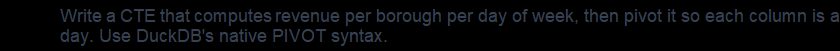

In [65]:
revenue_per_borough_per_day = con.execute("""WITH rev_by_day AS (
    SELECT
        b.borough,
        DAYNAME(pickup_dt) AS day_name,
        SUM(total_amount) AS daily_revenue_usd
    FROM taxi_clean tc
    JOIN taxi_zones b
      ON tc.pickup_zone = b.zone_id
    GROUP BY b.borough, DAYNAME(pickup_dt)
)
SELECT *
FROM rev_by_day
PIVOT (
    SUM(daily_revenue_usd) FOR day_name IN (
        'Monday'   AS Monday,
        'Tuesday'  AS Tuesday,
        'Wednesday' AS Wednesday,
        'Thursday' AS Thursday,
        'Friday'   AS Friday,
        'Saturday' AS Saturday,
        'Sunday'   AS Sunday
    )
) AS p;
""").df()
print(revenue_per_borough_per_day.to_string())

         borough        Monday       Tuesday     Wednesday      Thursday        Friday      Saturday        Sunday
0  Staten Island  1.845940e+03  1.073010e+03  1.344370e+03  9.643200e+02  7.132800e+02  1.418030e+03  1.506630e+03
1            N/A  2.285941e+04  2.299363e+04  2.279908e+04  2.369145e+04  2.188189e+04  2.115264e+04  2.592734e+04
2        Unknown  1.058324e+05  1.118200e+05  1.229600e+05  1.372608e+05  1.188054e+05  1.178301e+05  1.067516e+05
3          Bronx  1.022657e+05  1.033095e+05  1.153530e+05  1.229928e+05  1.314241e+05  8.021920e+04  8.829788e+04
4            EWR  2.726240e+03  1.616550e+03  2.785810e+03  3.436170e+03  2.471060e+03  2.026040e+03  2.548190e+03
5       Brooklyn  3.683056e+05  3.657052e+05  3.911204e+05  4.343027e+05  4.380902e+05  3.982212e+05  4.342277e+05
6      Manhattan  2.160298e+07  2.602122e+07  2.955808e+07  3.244062e+07  2.921765e+07  2.947194e+07  2.296601e+07
7         Queens  9.456412e+06  7.989179e+06  7.950691e+06  8.480151e+06  8.2004

Insight: Joining a 9-million-row Parquet file to a 265-row CSV (taxi_zones) is a broadcast join in DuckDB,
the small table is replicated to all threads, so there is no shuffle cost. The CTE chain keeps
each logical step named and testable. Adding the revenue_share_pct window function in Step B
avoids a self-join or subquery, the window runs over the already-grouped result.

----------------Partition, export and local data lake---------------

Writing a remote Parquet dataset to a local Hive-partitioned folder structure. Querying the local store with glob patterns and hive_partitioning=true for partition pruning. Comparing query performance before and after materialising locally.
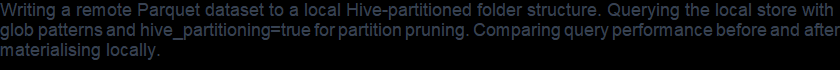

In [73]:
#Materialise a clean local copy, partitioned by month and borough
import os, time

os.makedirs('data/taxi_lake', exist_ok=True)

# Join clean trips with zones, then partition by year+month and borough
# This runs once, subsequent exercises use the local files
t0 = time.perf_counter()

con.execute("""
  COPY (
    SELECT
      t.*,
      z.borough,
      z.zone_name   AS pickup_zone_name,
      YEAR(t.pickup_dt)                          AS year,
      MONTH(t.pickup_dt)                         AS month
    FROM taxi_clean t
    JOIN taxi_zones z ON t.pickup_zone = z.zone_id
  )
  TO 'data/taxi_lake'
  (FORMAT PARQUET,
   PARTITION_BY (year, month, borough),
   COMPRESSION ZSTD,
   OVERWRITE_OR_IGNORE true)
""")

elapsed = time.perf_counter() - t0
print(f'Materialised in {elapsed:.1f}s')

# Show the partition tree
for root, dirs, files in os.walk('data/taxi_lake'):
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path) / 1e6
        print(f'{path}  ({size:.1f} MB)')

Materialised in 1.8s
data/taxi_lake\year=2002\month=12\borough=Manhattan\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2008\month=12\borough=Manhattan\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2009\month=1\borough=Manhattan\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2009\month=1\borough=Queens\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2023\month=12\borough=Manhattan\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2023\month=12\borough=Queens\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2024\month=1\borough=Bronx\data_0.parquet  (0.1 MB)
data/taxi_lake\year=2024\month=1\borough=Brooklyn\data_0.parquet  (0.5 MB)
data/taxi_lake\year=2024\month=1\borough=EWR\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2024\month=1\borough=Manhattan\data_0.parquet  (50.0 MB)
data/taxi_lake\year=2024\month=1\borough=N%2FA\data_0.parquet  (0.0 MB)
data/taxi_lake\year=2024\month=1\borough=Queens\data_0.parquet  (5.6 MB)
data/taxi_lake\year=2024\month=1\borough=Staten%20Island\data_0.parquet  (0.0 MB)
data

query the local lake with partition pruning

In [74]:
#register the local lake as a view with hive_partitioning enabled
con.execute("""
  CREATE OR REPLACE VIEW taxi_lake AS
  SELECT * FROM read_parquet(
    'data/taxi_lake/**/*.parquet',
    hive_partitioning = true
  )
""")

In [75]:
# This reads ONLY the Manhattan / month=1 partition folder
t0 = time.perf_counter()
result = con.execute("""
  SELECT
    pickup_zone_name,
    COUNT(*)                      AS trips,
    ROUND(SUM(total_amount), 0)   AS revenue
  FROM taxi_lake
  WHERE year = 2024
    AND month = 1
    AND borough = 'Manhattan'
  GROUP BY pickup_zone_name
  ORDER BY revenue DESC
  LIMIT 10
""").df()
print(f'Query: {time.perf_counter()-t0:.3f}s')
print(result.to_string())

Query: 0.032s
               pickup_zone_name   trips    revenue
0                Midtown Center  140067  3354610.0
1         Upper East Side South  140060  2770770.0
2     Times Sq/Theatre District  102887  2763814.0
3         Upper East Side North  133899  2712700.0
4  Penn Station/Madison Sq West  102096  2461254.0
5                  Midtown East  104294  2433123.0
6           Lincoln Square East  101710  2169640.0
7                 Midtown North   83631  1970372.0
8                  East Chelsea   75496  1867117.0
9                   Murray Hill   80922  1864804.0


Export a summary report to CSV + Parquet

In [76]:
os.makedirs('data/reports', exist_ok=True)

In [72]:
# Monthly revenue report — one row per month × borough
con.execute("""
  COPY (
    SELECT
      year, month, borough,
      COUNT(*)                            AS trips,
      ROUND(SUM(total_amount), 2)         AS revenue,
      ROUND(AVG(fare_amount), 2)          AS avg_fare,
      ROUND(AVG(tip_pct), 1)              AS avg_tip_pct,
      ROUND(AVG(duration_mins), 1)        AS avg_duration_mins
    FROM taxi_lake
    GROUP BY year, month, borough
    ORDER BY year, month, borough
  )
  TO 'data/reports/monthly_by_borough.parquet'
  (FORMAT PARQUET, COMPRESSION ZSTD)
""")


In [77]:
# Also export as CSV for stakeholders who don't use Parquet
con.execute("""
  COPY (SELECT * FROM 'data/reports/monthly_by_borough.parquet')
  TO 'data/reports/monthly_by_borough.csv'
  (HEADER true, DELIMITER ',')
""")
print('Exported Parquet + CSV to data/reports/')


Exported Parquet + CSV to data/reports/


Exercise: About the first query from this section, how large is the full local lake in MB? How does it compare to the aprox 135 MB of the 3 source parquet files?

In [79]:
size = con.execute("""SELECT
    ROUND(SUM(total_compressed_size) / 1024.0 / 1024.0, 2) AS lake_size_mb
FROM parquet_metadata('data/taxi_lake/**/*.parquet');
""").df()
print(size.to_string())

   lake_size_mb
0        170.21


Exercise: Use EXPLAIN SELECT ... FROM taxi_lake WHERE borough = 'Bronx' to confirm DuckDB is pruning partitions (look for 'Hive Partition Pushdown' in the plan).

In [80]:
pruning_check = con.execute ("""EXPLAIN SELECT * FROM taxi_lake WHERE borough = 'Bronx';
""").df()
print(pruning_check)

     explain_key                                      explain_value
0  physical_plan  ┌───────────────────────────┐\n│        READ_P...


Exercise: Add a fourth partition level, day of week, by including DAYOFWEEK(pickup_dt) AS dow in the COPY query and adding it to PARTITION_BY. Query only weekends (dow IN (1,7)).

In [82]:
con.execute("""
COPY (
    SELECT
        tc.*,
        tz.borough,
        YEAR(tc.pickup_dt)   AS year,
        MONTH(tc.pickup_dt)  AS month,
        DAYOFWEEK(tc.pickup_dt) AS dow
    FROM taxi_clean tc
    JOIN taxi_zones tz
      ON tc.pickup_zone = tz.zone_id
) TO 'data/taxi_lake_v2'
  (FORMAT PARQUET,
   PARTITION_BY (year, month, borough, dow),
   COMPRESSION ZSTD,
   OVERWRITE_OR_IGNORE true);
""")

In [83]:
con.execute("""CREATE OR REPLACE VIEW taxi_lake_v2 AS
SELECT *
FROM read_parquet('data/taxi_lake_v2/**/*.parquet', hive_partitioning = true);
""")

In [84]:
weekend_trips = con.execute("""SELECT
    borough,
    COUNT(*)               AS weekend_trips,
    ROUND(SUM(total_amount), 0) AS weekend_revenue_usd
FROM taxi_lake_v2
WHERE dow IN (1,7)               -- Sunday or Saturday
GROUP BY borough
ORDER BY weekend_revenue_usd DESC;
""").df()
print(weekend_trips.to_string())

         borough  weekend_trips  weekend_revenue_usd
0      Manhattan         945477           21602985.0
1         Queens         129647            9456412.0
2       Brooklyn          11017             368306.0
3        Unknown           3530             105832.0
4          Bronx           2791             102266.0
5            N/A            300              22859.0
6            EWR             28               2726.0
7  Staten Island             33               1846.0


Insight: Once you have a local partitioned lake you are no longer dependent on the network for every query,
use the remote view for ingestion, the local lake for analysis. The COPY pattern (remote -> local)
is how data engineers build cost-efficient self-contained pipelines without a warehouse.